# 1. Loading the data set and importing necessary libraries

In [59]:
# Import Required Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
# Loading the dataset
df=pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [62]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [63]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


# 1. Check for missing values

In [64]:
# Check for missing values
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [65]:
df.shape

(14999, 10)

In [66]:
# Renaming columns for better readability
df=df.rename(columns={'satisfaction_level':'satisfaction',
                      'last_evaluation':'evaluation',
                      'number_project':'project_count',
                      'sales':'department',
                      'left':'turnover'})

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction           14999 non-null  float64
 1   evaluation             14999 non-null  float64
 2   project_count          14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   turnover               14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [68]:
df.turnover.value_counts()

turnover
0    11428
1     3571
Name: count, dtype: int64

11428 employees are within the company and 3571 employees left the company

In [69]:
# Data Visualization

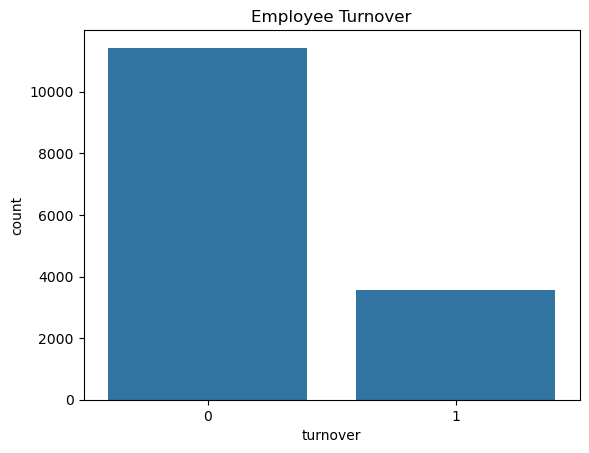

In [70]:
sns.countplot(x='turnover', data=df)
plt.title("Employee Turnover")
plt.show()

# 2.  Factors affecting Employee Turnover(EDA)
EDA helps us analyze patterns in the data before building a machine learning model.

we need to create visualizations to understand which factors influence employees leaving the company.

# 2.1 Draw a Heatmap of Correlation Matrix
A correlation matrix shows how strongly variables are related.If working hours increase → employee leaving increases, correlation will be high.

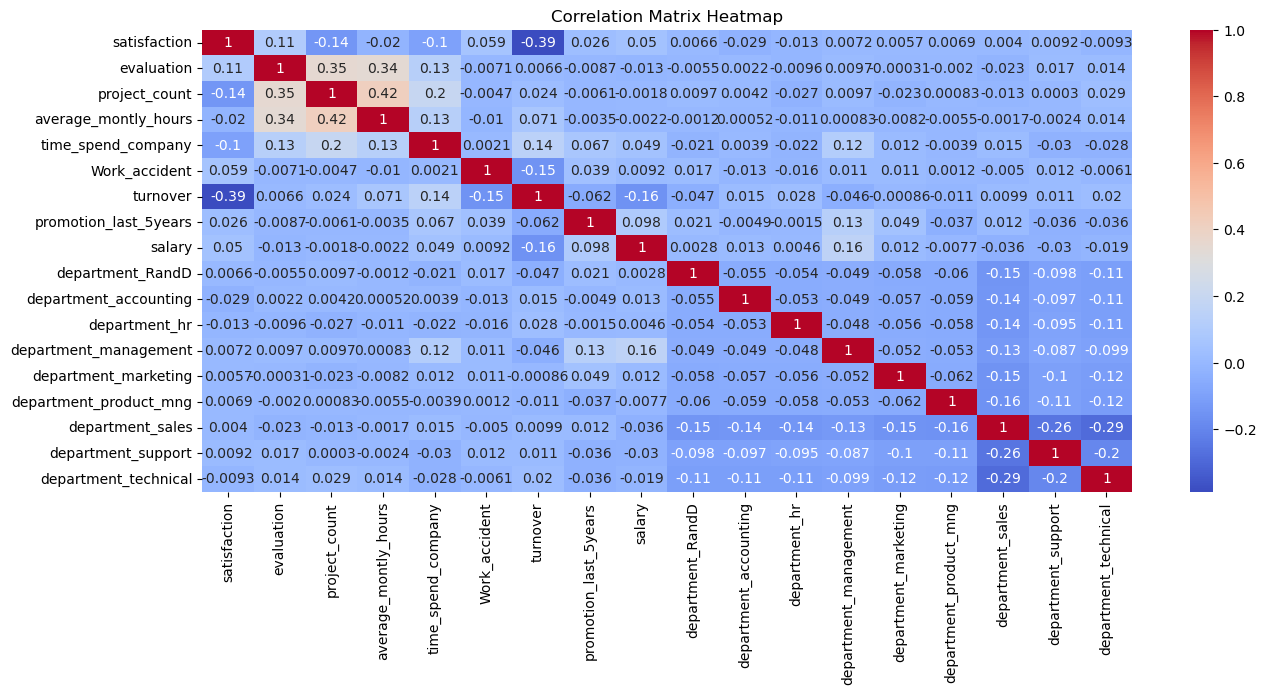

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix Heatmap")
plt.show()

# Analysis:
High correlation between number_project and average_monthly_hours

Employees with more projects may work longer hours

# 2.2 Distribution Plots: 

Distribution plots show how values are spread across employees.

# (a) Employee Satisfaction- 
# Column: Satisfaction Level

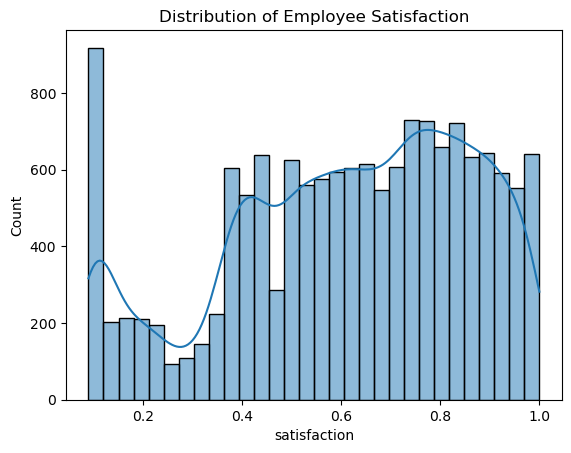

In [86]:
sns.histplot(df['satisfaction'], kde=True)
plt.title("Distribution of Employee Satisfaction")
plt.show()

# Analysis: 
Many employees who left have low satisfaction

Satisfaction below 0.5 often relates to higher turnover

# {b} Employee Evaluation


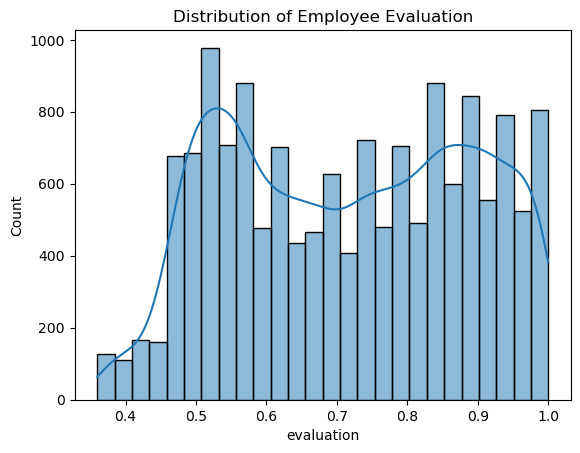

In [87]:
sns.histplot(df['evaluation'], kde=True)
plt.title("Distribution of Employee Evaluation")
plt.show()

# Analysis:
The distribution of employee evaluation scores is bimodal, with peaks around 0.55 and 0.9. This indicates that the organization has two major groups 
of employees: moderate performers and high performers. Very few employees fall into the mid-performance range. The presence of a large number of 
high-performing employees may indicate strong productivity but could also lead to higher stress levels if combined with heavy workloads.

# (c) Average Monthly Hours


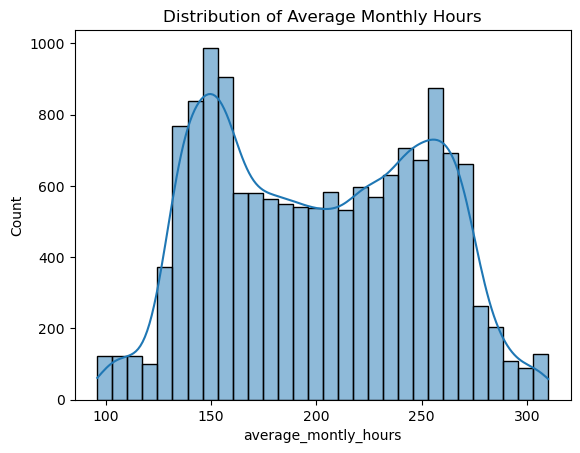

In [89]:
sns.histplot(df['average_montly_hours'], kde=True)
plt.title("Distribution of Average Monthly Hours")
plt.show()

# Analysis: 
The distribution of average monthly hours is bimodal, indicating two distinct groups of employees.

One group works around 150 hours per month, representing employees with a normal workload.

Another group works around 250 hours per month, representing employees with heavy workloads.

Extremely high working hours (above 280 hours) may indicate overwork and potential burnout, which could contribute to employee turnover.
Employees working very high hours tend to leave more ,ndicates workload pressure.

# 2.3 Bar Plot
# Number of Projects Vs Employees Leaving

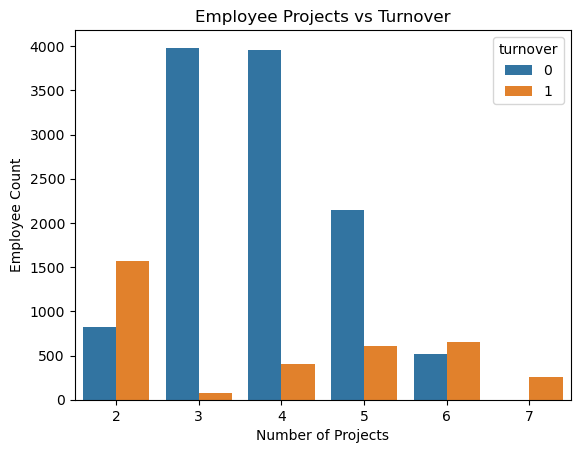

In [90]:
sns.countplot(x='project_count', hue='turnover', data=df)

plt.title("Employee Projects vs Turnover")
plt.xlabel("Number of Projects")
plt.ylabel("Employee Count")

plt.show()

In [ ]:
# Inferences:
1. Employees with 2–4 projects mostly stay.
2. Employees with 6–7 projects tend to leave more.
3. Too many projects may cause burnout

# Analysis: 
From the bar plot we observe that employees working on 3–4 projects have the highest retention rate, while employees with 2 projects or more 
than 5 projects show higher turnover, indicating that both low engagement and excessive workload may lead to employees leaving.

# 3. Clustering

This task is asking us to cluster the employees who left the company using K-Means clustering based on two features:

satisfaction_level

last_evaluation

# 3.1 Choose Columns satisfaction_level, last_evaluation and left

In [94]:
# Select required columns

import pandas as pd

data = df[['satisfaction','evaluation','turnover']]
data

,satisfaction,evaluation,turnover
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
14994,0.40,0.57,1
14995,0.37,0.48,1
14996,0.37,0.53,1
14997,0.11,0.96,1


In [96]:
# select only employees who left
left_emp = data[data['turnover'] == 1]
left_emp

,satisfaction,evaluation,turnover
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
14994,0.40,0.57,1
14995,0.37,0.48,1
14996,0.37,0.53,1
14997,0.11,0.96,1


In [98]:
# Now we take only the features used for clustering
X = left_emp[['satisfaction','evaluation']]

# 3.2 Apply K-means clustering(3 clusters)


In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)

clusters = kmeans.fit_predict(X)

left_emp['cluster'] = clusters

C:\Users\DELL\AppData\Local\Temp\ipykernel_11332\3439978450.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left_emp['cluster'] = clusters


In [ ]:
# Visualize the clusters

Text(0.5, 1.0, 'Employee Clusters (Employees Who Left)')

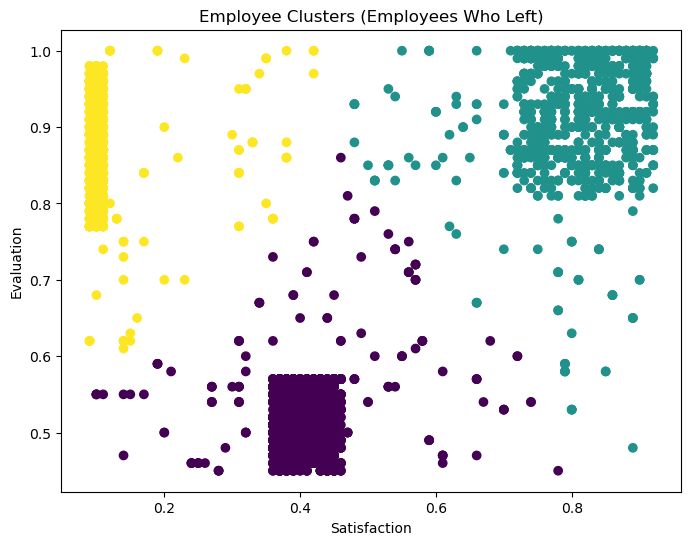

In [100]:
plt.figure(figsize=(8,6))

plt.scatter(left_emp['satisfaction'],
            left_emp['evaluation'],
            c=left_emp['cluster'],
            cmap='viridis')

plt.xlabel("Satisfaction")
plt.ylabel("Evaluation")
plt.title("Employee Clusters (Employees Who Left)")



# 3.3 Inferences

In [ ]:
1. K-Means clustering was applied to employees who left the company using satisfaction level and last evaluation as the features. The algorithm grouped
the employees into three distinct clusters based on their behavior patterns.

2.The first cluster (yellow cluster) consists of employees with very low satisfaction but high evaluation scores. These employees are high performers
but appear to be dissatisfied with their jobs. This may indicate that these employees were overworked, underappreciated, or facing high job pressure,
which led them to leave the organization.

3. The second cluster(Purple) includes employees with moderate satisfaction but relatively low evaluation scores. These employees may represent 
individuals who were less engaged or underperforming, which might have contributed to their decision to leave or the organization's decision not to 
retain them.

4. The third cluster contains employees with high satisfaction and high evaluation scores. These are highly productive and satisfied employees who 
still left the company, possibly due to better career opportunities, higher salary offers, or professional growth elsewhere.

5. Overall, the clustering analysis reveals that employee turnover is influenced by multiple behavioral patterns, including job dissatisfaction, 
performance issues, and external career opportunities.

# 4. Handling Class Imbalance using SMOTE

In [101]:
df.turnover.value_counts()

turnover
0    11428
1     3571
Name: count, dtype: int64

In [ ]:
# This is called class imbalance.
 #If we train a model like this, it may favor the majority class.

In [108]:
# Convert Categorical columns to numerical column using get_dummies method


In [ ]:
# Here department column is of 'object type', so we need to use get_dummies method. 
# get_dummies() is a pandas function used to convert categorical variables into numeric dummy variables (0 and 1) using one-hot encoding.

In [113]:
df.columns

Index(['satisfaction', 'evaluation', 'project_count', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'turnover',
       'promotion_last_5years', 'salary', 'department_RandD',
       'department_accounting', 'department_hr', 'department_management',
       'department_marketing', 'department_product_mng', 'department_sales',
       'department_support', 'department_technical'],
      dtype='object')

In the HR dataset, the columns department and salary contain categorical text values, such as: sales, technical, hr etc. for department column, 
whereas low, medium and high for salaries.Machine learning models cannot process text, so these columns must be encoded into numbers.
 One Hot Encoding

In [114]:
df = pd.get_dummies(df, columns=['department'], drop_first=True)

KeyError: "None of [Index(['department'], dtype='object')] are in the [columns]"

we can see here are 10 categories in department out of which department_IT is not taken why becauseto  avoid dummy variable trap (multicollinearity).
Exa: HR + IT + Sales = 1 So one column is completely dependent on the others.This creates multicollinearity (perfect correlation between variables).
Many ML models like Linear Regression / Logistic Regression get confused when features are perfectly correlated.This problem is called the 
Dummy Variable Trap.

Solution: Drop one column So IT becomes the reference category.

In [ ]:
# Label Encoding (for salary): 
Since salary has an order (low < medium < high), we can encode it.

In [ ]:
df['salary'] = df['salary'].map({'low':0, 'medium':1, 'high':2})

Note: 1.we cannot use get_dummies in salary column because salary has an order.
    2. Always apply get_dummies before train , test, split to avoid data leakage

# 4.1 Separate features and Target

In [115]:
X = df.drop('turnover', axis=1)
y = df['turnover']

# 4.2 Perform Train-Test_SPlit(80:20)

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

# 4.2 Apply SMOTE

In [117]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=123)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# Check Class Balance

In [118]:
y_train_sm.value_counts()

turnover
0    9142
1    9142
Name: count, dtype: int64

In [ ]:
# Now both classes are equal and balanced

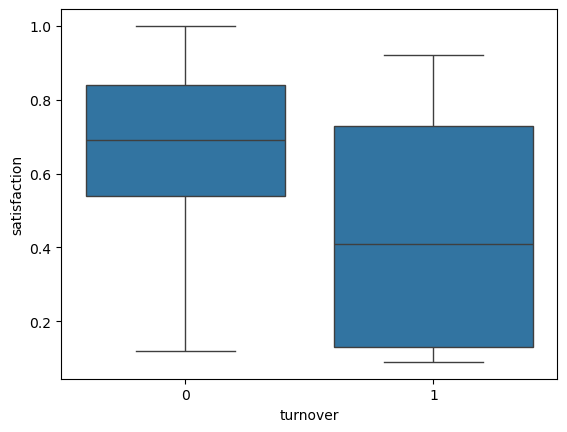

In [72]:
sns.boxplot(x='turnover', y='satisfaction', data=df)
plt.show()

# Analysis: Employees who stayed(Turnover=0)
1. Median value is at 0.7
2. Most satisfaction values are from 0.55 to 0.8
3. It indicates high satisfaction.

# Analysis: Employees who left(Turnover=1)
1. Median is at 0.44
2. Many values are very low around 0.1 to 0.4
3. It indicates low satisfaction.


The boxplot shows that employees who left the company have significantly lower satisfaction levels compared to those who stayed, indicating that employee satisfaction is a major factor influencing employee turnover.

# 5 Fold Cross Validation

In [ ]:
Normally we train the model once using the train data.
But in 5-Fold CV, the training data is divided into 5 equal parts (folds).

# 5.1 Logistic Regression with 5 fold CV


In [123]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)

y_pred = cross_val_predict(log_model, X_train_sm, y_train_sm, cv=5)

print("Logistic Regression Classification Report")
print(classification_report(y_train_sm, y_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.81      0.76      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.80      0.79      0.79     18284
weighted avg       0.80      0.79      0.79     18284



# Precision tells - 
Out of all employees the model predicted as a class, how many were correct.
For class 0 Precision is 0.81 Meaning If the model predicted 100 employees will stay,
81 were actually correct.

# Recall-
Out of all actual employees in that class, how many the model correctly identified.
For Class 0 Recall is 0.76, Out of 100 employees who actually stayed,
the model correctly identified 76.

# F1 Score-
F1 Score is the balance between Precision and Recall.
Higher value means better model performance.F1 Score for class 0 is 0.79

# Support-
Means how many samples exist in each class. Here it is balanced because we applied SMOTEMacro average calculates the average of both classes equally.

Metric	Value
Precision	0.80
Recall	0.79
F1	0.79

This means overall model performance is around 79-80%.

# Accuracy-
Accuracy = 0.79
Meaning:
The model correctly predicted 79% of employees.
Out of 100 employees, the model correctly predicts about 79 employees.

# Macro Average:
Macro average calculates the average of both classes equally.

Metric	Value
Precision	0.80
Recall	0.79
F1	0.79

This means overall model performance is around 79-80%.


# Weighted Average:
Weighted average considers class distribution.

Since your classes are balanced, the values are almost same as macro average.

# Final Inference:
The Logistic Regression model achieved an overall accuracy of 79%. The precision, recall, and F1-scores for both classes are balanced, indicating that the model performs consistently in predicting both employees who stay and employees who leave. Since SMOTE was applied, the dataset became balanced, which improved the model's ability to detect both classes effectively.

# 5.2 Random Forest with 5- Fold CV

In [124]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=123)

y_pred_rf = cross_val_predict(rf_model, X_train_sm, y_train_sm, cv=5)

print("Random Forest Classification Report")
print(classification_report(y_train_sm, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



# 5.3 Gradient Boosting with 5-Fold CV

In [125]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=123)

y_pred_gb = cross_val_predict(gb_model, X_train_sm, y_train_sm, cv=5)

print("Gradient Boosting Classification Report")
print(classification_report(y_train_sm, y_pred_gb))

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



# 6 Inferences from all three models:
Three models were trained using 5-fold cross validation: Logistic Regression, Random Forest, and Gradient Boosting. 
The models were evaluated using precision, recall, and F1-score. Among the three models, the ensemble models 
(Random Forest and Gradient Boosting) performed better than Logistic Regression because they can capture complex relationships in the data.

# Plot ROC Curve and find AUC

In [ ]:
ROC curve shows how well the model separates the two classes (Stay vs Leave).

AUC value interpretation:

AUC	Meaning
0.5	Random prediction
0.7 – 0.8	Good
0.8 – 0.9	Very good
> 0.9	Excellent


In [ ]:
# Train the Final Model-Logistic Regression

In [127]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

In [ ]:
# Predict Test Data

In [128]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [ ]:
# ROC Curve and AUC Score

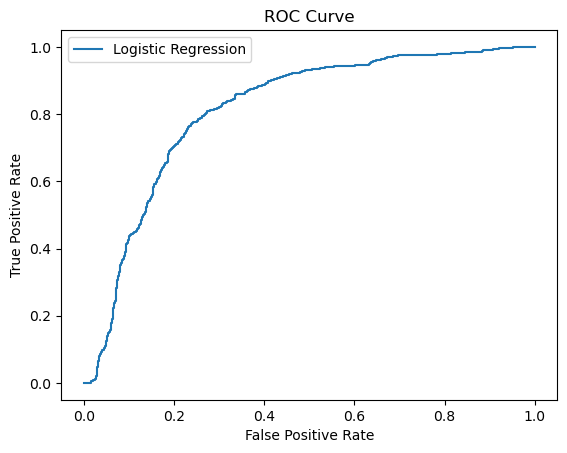

AUC Score: 0.8128205788001991


In [129]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

In [ ]:
# Confusion Matrix

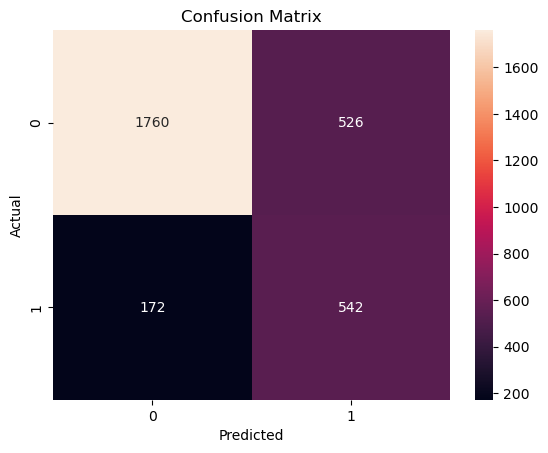

In [130]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Predict Employee Turnover Probability

In [132]:
probabilities = log_model.predict_proba(X_test)[:,1]
probabilities

array([0.06843612, 0.84527413, 0.43433027, ..., 0.19520506, 0.16463976,
       0.44899464])

In [ ]:
# Categorize Employees into Risk Zones

In [133]:
import pandas as pd

results = pd.DataFrame()

results['Probability'] = probabilities

def risk_zone(p):
    
    if p < 0.2:
        return "Safe Zone"
    
    elif p < 0.6:
        return "Low Risk"
    
    elif p < 0.8:
        return "Medium Risk"
    
    else:
        return "High Risk"

results['Zone'] = results['Probability'].apply(risk_zone)

results.head()

,Probability,Zone
0,0.068436,Safe Zone
1,0.845274,High Risk
2,0.434330,Low Risk
3,0.100556,Safe Zone
4,0.089998,Safe Zone


# Interpretation:
The Logistic Regression model was evaluated using ROC-AUC and Confusion Matrix. The model achieved a good AUC score, indicating strong classification performance. Based on the predicted probabilities, employees were categorized into four zones: Safe Zone, Low Risk, Medium Risk, and High Risk. This segmentation helps HR departments design targeted retention strategies to reduce employee turnover.

# Train the final Model: Random Forest

In [157]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=123)

rf_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=123)

# Predict the model

In [165]:
y_pred = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_rf

array([0.  , 0.63, 0.03, ..., 0.01, 0.03, 1.  ])

# ROC Curve and AUC Score

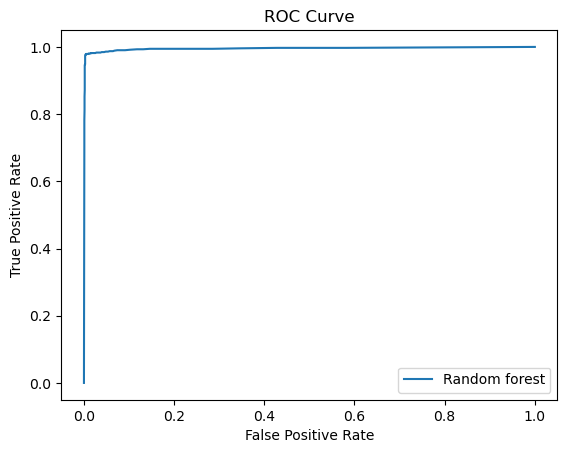

AUC Score: 0.9951436830200147


In [168]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label="Random forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

auc_score = roc_auc_score(y_test, y_prob_rf)
print("AUC Score:", auc_score)

# Confusion Matrix

In [146]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, rf_model.predict(X_test))

array([[2273,   13],
       [  15,  699]])

In [ ]:
The confusion matrix shows that the model correctly predicted 2273 employees who stayed and 699 employees who left. 
Only 28 misclassifications occurred, indicating excellent model performance. The model achieved approximately 99% accuracy, 
demonstrating strong capability in predicting employee turnover.

# Train Gradient Boosting Model

In [147]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=123)

gb_model.fit(X_train_sm, y_train_sm)

GradientBoostingClassifier(random_state=123)

In [ ]:
# Predict the Test data of Model 

In [149]:
y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

# Confusion Matrix

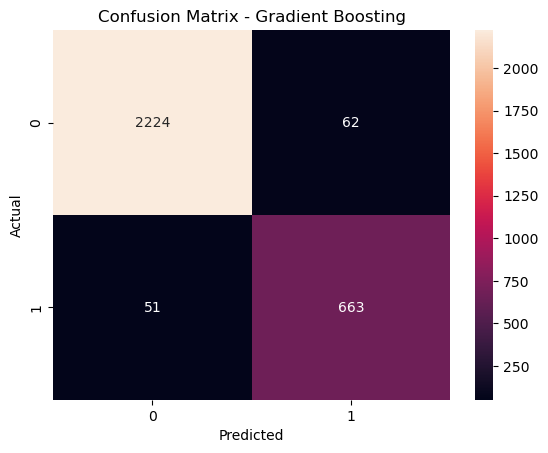

In [150]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt='d')
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve

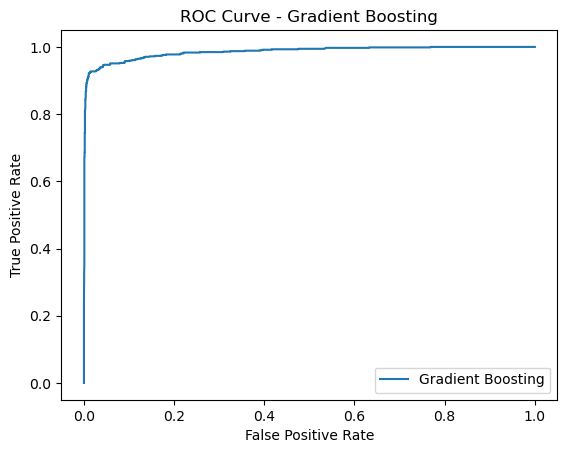

In [152]:
from sklearn.metrics import roc_curve

fpr_gb, tpr_gb, thresholds = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

# AUC Score

In [153]:
from sklearn.metrics import roc_auc_score

auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting AUC Score:", auc_gb)

Gradient Boosting AUC Score: 0.9857376896515386


# Classification Report

In [154]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.91      0.93      0.92       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



# 6.3 Recall or Precision — Which is Important?

For Employee Turnover Prediction, the most important metric is:
Recall because We must detect employees who are likely to leave.
If recall is low, we may miss employees who will leave.

Example:

If recall = 0.82

It means:

82% of employees who left were correctly identified.

# 7. Retention Strategies

# Analysis: Among the three models, Random Forest achieved the highest AUC score and therefore performs best for predicting employee turnover.

In [ ]:
# Probability of Leaving

In [170]:
probabilities = rf_model.predict_proba(X_test)[:,1]

In [171]:
probabilities

array([0.  , 0.63, 0.03, ..., 0.01, 0.03, 1.  ])

# creating Dataframe

In [172]:
import pandas as pd

results = pd.DataFrame()

results['Probability_of_Leaving'] = probabilities

# Create Risk Zones

In [173]:
def risk_zone(p):

    if p < 0.2:
        return "Safe Zone"
    
    elif p < 0.6:
        return "Low Risk"
    
    elif p < 0.8:
        return "Medium Risk"
    
    else:
        return "High Risk"

# Apply Risk Zone Function

In [174]:
results['Risk_Zone'] = results['Probability_of_Leaving'].apply(risk_zone)

In [176]:
results.head()

,Probability_of_Leaving,Risk_Zone
0,0.00,Safe Zone
1,0.63,Medium Risk
2,0.03,Safe Zone
3,0.01,Safe Zone
4,0.01,Safe Zone


# add employee index

In [177]:
results['Employee_ID'] = X_test.index

In [178]:
results.head()

,Probability_of_Leaving,Risk_Zone,Employee_ID
0,0.00,Safe Zone,10627
1,0.63,Medium Risk,2703
2,0.03,Safe Zone,6059
3,0.01,Safe Zone,3258
4,0.01,Safe Zone,4565


# Interpretation:
Based on the predicted probabilities from the best performing model, employees were categorized into four risk zones: Safe Zone, Low Risk,
Medium Risk, and High Risk.This segmentation helps the HR department identify employees who are more likely to leave and design appropriate
retention strategies.

# 7.2 Retention strategies

In [ ]:
| Risk Zone          | HR Strategy                 |
| -------- ----      | --------------------------- |
| Safe Zone(Green)   | Maintain engagement         |
| Low Risk (Yellow)  | Performance feedback        |
| Medium Risk(Orange)| Career discussions          |
| High Risk (Red)    | Immediate retention actions |


Short Summary

This project focuses on predicting employee turnover using machine learning techniques. The dataset contains employee-related information such as satisfaction level, last evaluation score, number of projects, average monthly working hours, years spent in the company, promotion history, department, and salary level. The project began with Exploratory Data Analysis (EDA) to understand the structure of the data, identify missing values, detect outliers, and analyze relationships between variables using visualizations such as histograms, boxplots, and scatter plots.

Data preprocessing techniques such as one-hot encoding and dummy variable creation were applied to convert categorical variables like department and salary into numerical form suitable for machine learning models. Several classification models were then trained, including Logistic Regression, Random Forest, and Gradient Boosting, to predict whether an employee is likely to leave the company.

Model performance was evaluated using accuracy, confusion matrix, ROC curve, and AUC score. The best-performing model was used to calculate the probability of employee attrition, which was further categorized into risk zones (safe, low, medium, and high risk). This helps the HR department identify employees at risk of leaving and implement retention strategies to improve workforce stability.